# Imports & Helper Functions
Check this code runs which means all the installations should be correct.

In [285]:
import cv2
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np

from os import listdir

import os

from sklearn.cluster import KMeans

# helper function to easily plot + save images at the same time - useful for debugging
def imshow(image, name="image.png", plot=True, write=True, cmap="gist_gray"):
    if write:
        bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        cv2.imwrite(name, bgr)
    if plot:
        plt.figure(figsize=(9, 9))
        plt.imshow(image, cmap=cmap)
        plt.axis('off')  
        
def load_rgb(path):
    img = cv2.imread(path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return rgb
# cv2 doesn't automatically load images in an RGB format but in a BGR format 
# so I wanted to create a helper function which helps with more easily plotting images


# Task 1 - Identifying the Canvas
- In order to extract the canvas from a screenshot of the GUI - canny edge detection can be used to segment large enclosed shapes. 

- We can follow the _assumption_ that the contour with the largest enclosed area within a design app screenshot is the canvas.

- Sometimes the canvas will intersect with the edge of the screenshot, which means the edge of the canvas will not be detected - to combat this we can add a border or padding to the image and then later remove it.

- The border colour is chosen based on whether the GUI is in light mode or dark mode
These assumptions can be made:
```
if the GUI is in light mode this usually means the canvas colour is dark
if the GUI is in dark mode this usally means the canvas colour is white
```
These assumptions do have limitations - when the canvas becomes much more complex and populated this method will likely be unsuccessful. 


- Once edges have been detected we can use `cv2.findContours` to find contours and then sort them in terms of area to find the largest enclosed contour

Resources:
- https://www.geeksforgeeks.org/python/adding-borders-to-the-images-using-python-opencv/
- https://www.learningaboutelectronics.com/Articles/How-to-find-the-largest-or-smallest-object-in-an-image-Python-OpenCV.php

Extension: Ideally I would want to find an algorithm to automatically identify whether a black or white border is needed to support edge detection i.e. working out whether the canvas is white or dark. An initial idea was to use the most common pixel colour to make a best guess. I could validate this by checking the canvas occupies a certain ratio of the screen. 

In [286]:
# Initial Implementation
def find_canvas(image, light_mode=True):
    if light_mode:
        val = 255 # border = white
    else:
        val = 0 # border = black
        
    pad = 10
    
    bordered_frame = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=[val, val, val])
    
    gray= cv2.cvtColor(bordered_frame,cv2.COLOR_BGR2GRAY)
    
    ret,thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    
    edges = cv2.Canny(thresh, 0, 200)
    # imshow(edges, write=False) # optional code to show inbetween step for debugging
    
    contours, hierarchy= cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    sorted_contours= sorted(contours, key=cv2.contourArea, reverse= True) # find largest contour area
    canvas_contour = sorted_contours[0] # the largest contour area will usually be the canvas; following assumptions laid out above
    
    return canvas_contour - pad # remove border from contours

## Testing with Figma

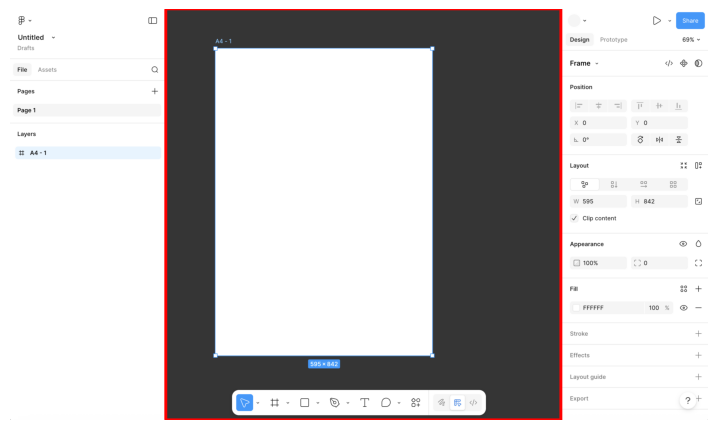

In [287]:
image = load_rgb('sample-data/figma.png')
canvas = find_canvas(image, light_mode=True)
cv2.drawContours(image, canvas, -1, (255,0,0),10)
imshow(image, write=False)

## Testing with Illustrator - including canvas occlusion 

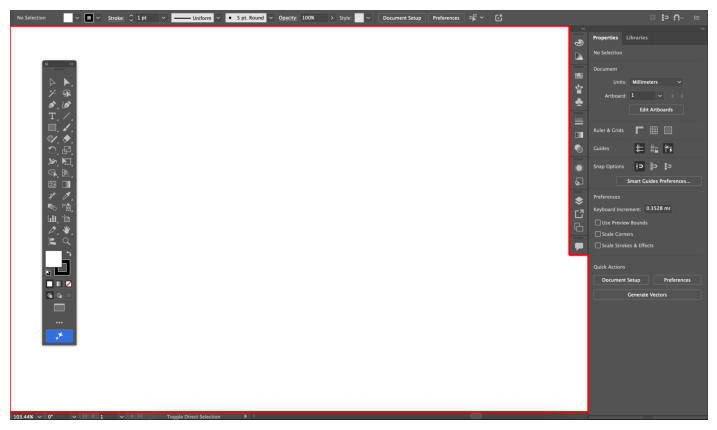

In [288]:
image = load_rgb('sample-data/illustrator-1.png')
canvas = find_canvas(image, light_mode=False)
cv2.drawContours(image, canvas, -1, (255,0,0),5)
imshow(image, write=False)

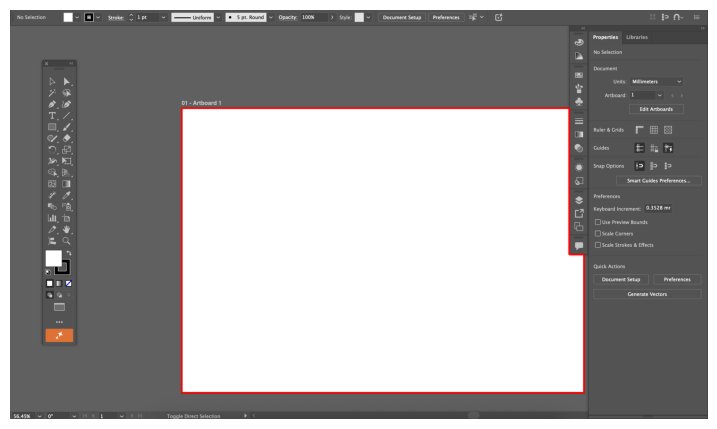

In [289]:
image = cv2.imread('sample-data/illustrator-3.png')
canvas = find_canvas(image, light_mode=False)
cv2.drawContours(image, canvas, -1, (255,0,0),5)
imshow(image, write=False)

## Extension/subtask - Automatically identifying canvas colour
Potential ideas:

1. Find most common pixel colour in an image (limitation: this doesn't necessarily correspond to canvas colour or lightmode or darkmode e.g. if th canvas has been zoomed out significantly in illustrator this wouldn't work)

2. Segment image based on colours (limitation: similar to first idea)

3. Take a segment of the screenshot (middle region) - following the assumption that the canvas is usually in the centre of the image and perform segmentation there.

4. Find a region of high entropy - this will suggest a region of dense icons rather than the blank canvas - then find the background colour for that region. May be possible to try top hat or bottom hat here ... do a bit more reading ...

---

# Task 2 - Extracting GUI Elements

Algorithm overview:
1. convert to grayscale - which is important before thresholding
2. manullay threshold
3. if in light-mode flip the image (if the screenshot is in light-mode this will mean the icons are black on a white background and we would want to flip this so that white presents positive values)
4. dilate the new image to merge small points between GUI icons together so they are a single blob - this will allow us to model each icon as a connected compoent
5. find connected components within a specific size range (area > 300) and (area < 9000) - these valually were manually discovered through iterative investigations (if I have time it would be good to update these from an area to a specific fraction of the screen they occupy so this method is transferrable to screenshots of different sizes)

In [290]:
def prepare_for_connected_components(image, light_mode=True):
    # this assumes the input image is in RGB space
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # ret, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    # I initially tried otsu's binarisation but found that manually defining thresholds works better:
    
    # binarise the image:
    ret, thresh = cv2.threshold(gray, 190, 255, cv2.THRESH_BINARY)
    
    # if the screenshot is in light-mode this will mean the icons are black on a white background and we would want to flip this
    if light_mode:
        pre_dilated = cv2.bitwise_not(thresh)
    else:
        pre_dilated = thresh
    
    # by dilating the image this will cause small points between icons to become merged together e.g. a single blob
    # this will allow us to model each icon as a connected compoent
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11))
    dilated = cv2.dilate(pre_dilated,kernel,iterations = 1)
    # as an alternative a closing operation could be used which would close small gaps between objects - but dilation works well enough here
    
    return dilated
        

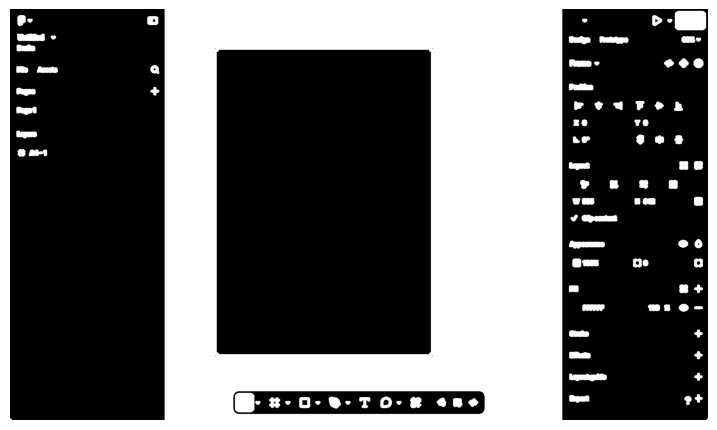

In [291]:
image = load_rgb('sample-data/figma.png')
processed = prepare_for_connected_components(image)
imshow(processed, write=False)

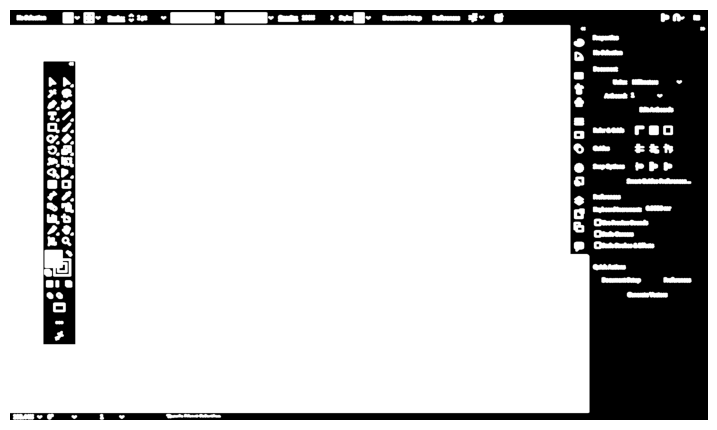

In [292]:
image = load_rgb('sample-data/illustrator-1.png')
processed = prepare_for_connected_components(image, light_mode=False)
imshow(processed, write=False)

In [293]:
def extract_icons(image, light_mode=True, save_icons=True, icon_list="dataset-1", smallest_ratio=0.00009, largest_ratio=0.0213):
    processed = prepare_for_connected_components(image, light_mode)
    
    analysis = cv2.connectedComponentsWithStats(processed, 4, cv2.CV_32S) # what is CV_32S? would be good to research more
    
    (totalLabels, label_ids, stats, centroids) = analysis
    
    img_h = image.shape[0]
    img_w = image.shape[1]
    
    img_area = img_h*img_w
    
    
    overlay = image.copy() # crete an overlay to place over the image
    cv2.rectangle(overlay, (0, 0), (img_w, img_h), (0, 0, 0), -1) # convert to a black overlay
    
    # add shading so icons are clearer to see
    alpha = 0.8 
    shaded = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0) # place shade over the original image
    bounding_boxes = shaded.copy()
    
    centres_dataset = []
    
    for i in range(1, totalLabels):
        area = stats[i, cv2.CC_STAT_AREA]  

        # original implementation:
        # if (area > 300) and (area < 9000):
        
        # updated to use a ratio instead of a hardcoded area for more genralisability over different image resolutions:
        if (area/img_area > smallest_ratio) and (area/img_area < largest_ratio):
            
            (cX, cY) = centroids[i]
            
            x = stats[i, cv2.CC_STAT_LEFT]
            y = stats[i, cv2.CC_STAT_TOP]
            w = stats[i, cv2.CC_STAT_WIDTH]
            h = stats[i, cv2.CC_STAT_HEIGHT]
            # area = stats[i, cv2.CC_STAT_AREA]
                
            cv2.rectangle(bounding_boxes, (x, y), (x+w, y+h), (255, 0, 0), 2)
            cropped_im = image[y:y+h, x:x+w]
            
            if save_icons:
                dataset_path = f"./icon-datasets/{icon_list}"
                
                if not os.path.exists(dataset_path):
                    os.makedirs(dataset_path)
                
                cv2.imwrite(f"{dataset_path}/icon-{i}.png", cropped_im) # save icon to a collection of icons for further analysis
                # these datasets can be useful for training future deep-learning models for recognising icons 
                # or for building sift recognisers
            
            centres_dataset.append([cX, cY])
        
    return bounding_boxes, centres_dataset
    

Finding out what a good icon ratio size would be:

In [294]:
image = load_rgb('sample-data/figma.png')
bounding_boxes, centres = extract_icons(image, light_mode=True, icon_list="dataset-1")

In [295]:
dataset = "icon-datasets/dataset-1"

img_sizes = []

for file in os.listdir(dataset):
    image = load_rgb(f'{dataset}/{file}')
    img_h = image.shape[0]
    img_w = image.shape[1]
    size = img_h*img_w
    img_sizes.append(size)

In [296]:
sorted_imgs = sorted(img_sizes)
print(sorted_imgs[0])
print(sorted_imgs[-1])

408
8806


In [297]:
image = load_rgb('sample-data/figma.png')
img_h = image.shape[0]
img_w = image.shape[1]
figam_size = img_h*img_w
print(figam_size)

4134000


In [298]:
print(408/413400)
print(8806/413400)

0.0009869375907111755
0.021301402999516206


- smallest icon ratio = 408/413400 is approx 0.0001
- largest icon ratio = 8806/413400 is approx 0.2

In [299]:
image = load_rgb('icon-datasets/dataset-1/icon-94.png')
img_h = image.shape[0]
img_w = image.shape[1]
img_h*img_w

1292

## Testing icon extraction with Figma

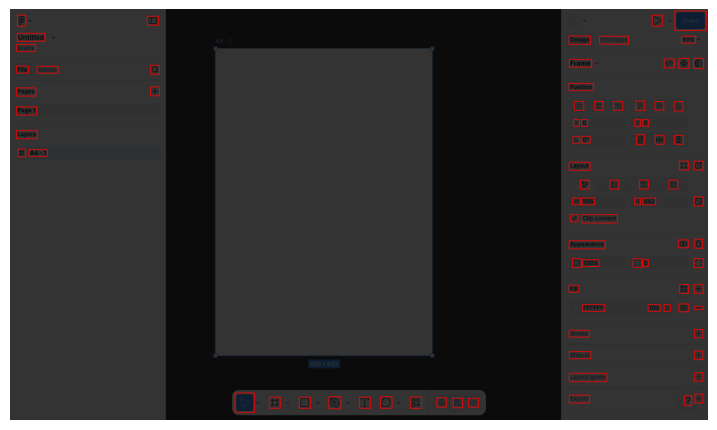

In [300]:
image = load_rgb('sample-data/figma.png')
bounding_boxes, centres = extract_icons(image, light_mode=True, icon_list="dataset-1")
imshow(bounding_boxes, write=False)

## Testing icon extraction with Illustrator

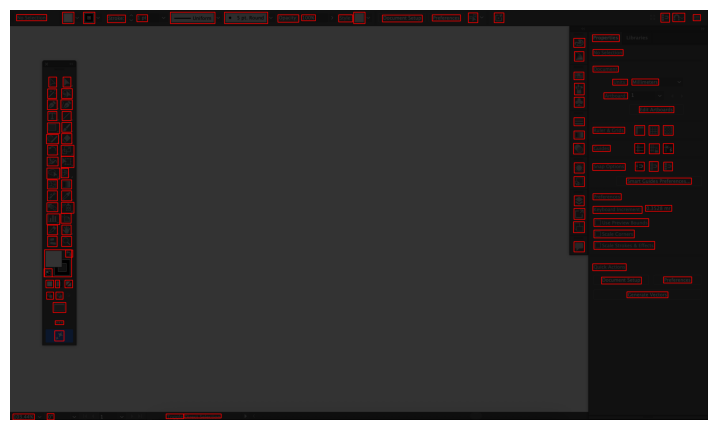

In [301]:
image = load_rgb('sample-data/illustrator-1.png')
bounding_boxes, centres = extract_icons(image, light_mode=False, icon_list="dataset-2")
imshow(bounding_boxes, write=False)

# Task 3 - Segmenting GUI icons
This can be useful for agentic AI systems e.g. if they want to investigate a specific toolset which may be in one specific segment or if the user doesn't want all information to be exposed at once.

In [302]:
def segment_GUI(image, centres_dataset, n_clusters=5):
    
    # use kmeans segmentation
    kmeans = KMeans(
    init="random",
    n_clusters=n_clusters,
    n_init=10,
    max_iter=300,
    random_state=42
    )
    
    img_h = image.shape[0]
    img_w = image.shape[1]   
    
    # this is just to initiate empty arrays of the right size
    x_min = [img_w] * n_clusters
    x_max = [0] * n_clusters
    y_min = [img_h] * n_clusters
    y_max = [0] * n_clusters
    colours = [0] * n_clusters

    kmeans.fit(centres_dataset)
    
    overlay = image.copy() # crete an overlay to place over the image
    cv2.rectangle(overlay, (0, 0), (img_w, img_h), (0, 0, 0), -1) # convert to a black overlay

    alpha = 0.8 
    shaded = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0) # place shade over the original image
    cluster_view = shaded.copy()
    
    for idx, p in enumerate(centres_dataset):
        x = int(p[0])
        y = int(p[1])
        
        cluster = kmeans.labels_[idx]
        
        if x < x_min[cluster]:
            x_min[cluster] = x
        if x > x_max[cluster]:
            x_max[cluster] = x
            
        if y < y_min[cluster]:
            y_min[cluster] = y
        if y > y_max[cluster]:
            y_max[cluster] = y
        
        hue = (356/n_clusters) * cluster
        
        hls = (hue, 50, 100)
        hls_conv = (hls[0]/2, hls[1]*2.55, hls[2]*2.55)
        rgb = cv2.cvtColor(np.uint8([[hls_conv]]), cv2.COLOR_HLS2RGB)[0][0]
        # https://stackoverflow.com/questions/66920286/opencv-converts-hsl-to-rgb (how to do colour conversions)
        colours[cluster] = rgb
        
        cv2.circle(cluster_view,(x,y), 15, (int(rgb[0]), int(rgb[1]), int(rgb[2])), -1)
    
        
    for idx, _ in enumerate(x_min):

        col = colours[idx]
           
        pad = 30
        
        x0 = max(0, x_min[idx] - pad)
        x1 = min(img_w, x_max[idx] + pad)

        y0 = max(0, y_min[idx] - pad)
        y1 = min(img_h, y_max[idx] + pad)
        
        cv2.rectangle(cluster_view, (x0, y0), (x1,y1), (int(col[0]), int(col[1]), int(col[2])), 2)
    
    return cluster_view, kmeans



## Testing segmentation in Figma

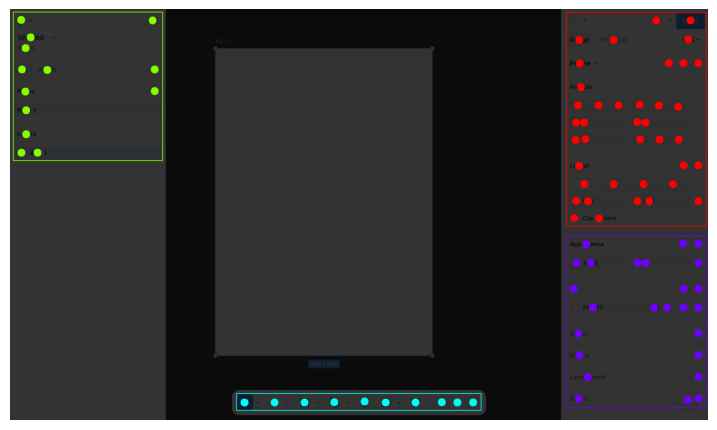

In [303]:
image = load_rgb('sample-data/figma.png')
bounding_boxes, centres = extract_icons(image, light_mode=True, save_icons=False)
cluster_img, kmeans = segment_GUI(image, centres, n_clusters=4)
imshow(cluster_img, write=False)

## Testing segmentation in Illustrator

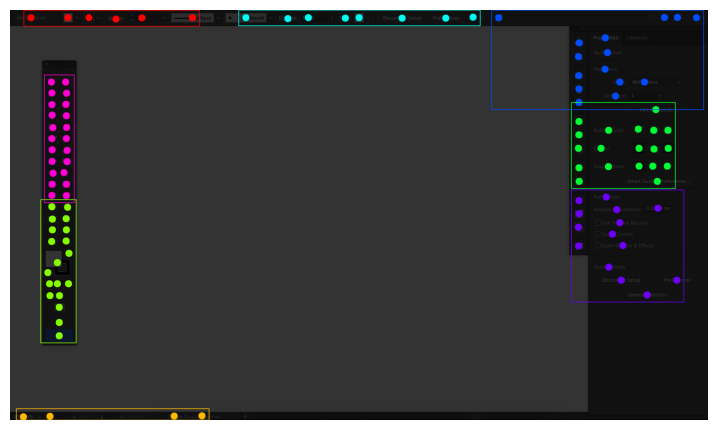

In [304]:
image = load_rgb('sample-data/illustrator-1.png')
bounding_boxes, centres = extract_icons(image, light_mode=False, save_icons=False) #forgot to set light mode to false before
cluster_img, kmeans = segment_GUI(image, centres, n_clusters=8)
imshow(cluster_img, write=False)

# Task 4 - Labelling/Matching GUI icons using SIFT
If the system knows the name of all the internal icons that it may be able to semantically label these segmented regions which could be helpful for further requests.

One way is to do this with SIFT

I complete a small test with just the tool-bar.
I had to manually label these images in `toolbar-dataset` - this works fine for small experiments but isn't very scalable and will not work well across platforms with different icon styles e.g. switching between figma and illustrator.

In [305]:
def load_images(folder_path):
    images = {}
    for filename in os.listdir(folder_path):
        image_path = os.path.join(folder_path, filename)
        img = load_rgb(image_path)
        if img is not None:
            images[filename] = img
    return images

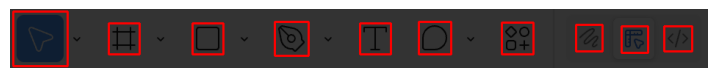

In [306]:
image = load_rgb('sample-data/figma-toolbar.png')
bounding_boxes, centres = extract_icons(image, light_mode=True, icon_list="toolbar-dataset", smallest_ratio=0.005, largest_ratio=0.5)
imshow(bounding_boxes, write=False)

In [307]:
def find_closest_match(image, dataset="./icon-datasets/labelled-toolbar-dataset/", light_mode=True):
    
    
    
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # binarise the image:
    ret, thresh = cv2.threshold(gray, 190, 255, cv2.THRESH_BINARY)
    
    if light_mode:
        input = cv2.bitwise_not(thresh)
    else:
        input = thresh
    
    # input = thresh
    
    sift = cv2.SIFT_create()
    bf = cv2.BFMatcher()   
     
    kp, des = sift.detectAndCompute(input,None)
    
    best = 0
    label = None

    features = load_images(dataset)
    # this is a dictionary of uniquely named images
    
    for tag, template_image in features.items():
        template = cv2.cvtColor(template_image, cv2.COLOR_RGB2GRAY)
        ret, thresh_template = cv2.threshold(template, 190, 255, cv2.THRESH_BINARY)
        
        if light_mode:
            input_template = cv2.bitwise_not(thresh_template)
        else:
            input_template = thresh_template
        
        kp_c, des_c = sift.detectAndCompute(input_template,None)
        
        if des_c is None:
            continue
        
        matches = bf.knnMatch(des,des_c,k=2)
        
    
        good = []
        for match in matches:
            if len(match) < 2:
                continue
            
            m, n = match
            
            if m.distance < 0.4*n.distance:
                good.append([m])
                
        candidate = len(good)
        if candidate > best:
            best = candidate
            label = tag[:-4]
        
    # return the assigned label and best score
    return label, best

In [308]:
features = load_images("./icon-datasets/labelled-toolbar-dataset/")

In [309]:
features.keys()

dict_keys(['design.png', 'actions.png', 'pen.png', 'move.png', 'draw.png', 'dev.png', 'shape.png', 'comment.png', 'frame.png', 'text.png'])

In [310]:
# small test to make sure it works on a single icon match
image = load_rgb('sample-data/pen.png')
find_closest_match(image)

('pen', 11)

In [311]:
def extract_and_label_icons(image, light_mode=True, dataset="./icon-datasets/labelled-toolbar-dataset/", smallest_ratio=0.00009, largest_ratio=0.0213):
    processed = prepare_for_connected_components(image, light_mode)
    
    analysis = cv2.connectedComponentsWithStats(processed, 4, cv2.CV_32S) # what is CV_32S? would be good to research more
    
    (totalLabels, label_ids, stats, centroids) = analysis
    
    img_h = image.shape[0]
    img_w = image.shape[1]
    
    img_area = img_h*img_w
    
    overlay = image.copy() # crete an overlay to place over the image
    cv2.rectangle(overlay, (0, 0), (img_w, img_h), (0, 0, 0), -1) # convert to a black overlay
    
    # add shading so icons are clearer to see
    alpha = 0.8 
    shaded = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0) # place shade over the original image
    bounding_boxes = shaded.copy()
    
    centres_dataset = []
    
    for i in range(1, totalLabels):
        area = stats[i, cv2.CC_STAT_AREA]  
        
        # updated to use a ratio instead of a hardcoded area for more genralisability over different image resolutions:
        if (area/img_area > smallest_ratio) and (area/img_area < largest_ratio):
            
            (cX, cY) = centroids[i]
            
            x = stats[i, cv2.CC_STAT_LEFT]
            y = stats[i, cv2.CC_STAT_TOP]
            w = stats[i, cv2.CC_STAT_WIDTH]
            h = stats[i, cv2.CC_STAT_HEIGHT]
            # area = stats[i, cv2.CC_STAT_AREA]
                
            cv2.rectangle(bounding_boxes, (x, y), (x+w, y+h), (50, 0, 0), 2)
            cropped_im = image[y:y+h, x:x+w]
            label, _ = find_closest_match(cropped_im, dataset)
            
            text_size = 0.55
            
            # x_pos = int(cX)
            x_pos = int(cX)-len(str(label))*8*text_size
            
            if label != None:
                cv2.putText(bounding_boxes, f"{label}", ((int(x_pos)), int(cY)), cv2.FONT_HERSHEY_SIMPLEX, text_size, (255, 0, 0), 2)
            
    return bounding_boxes

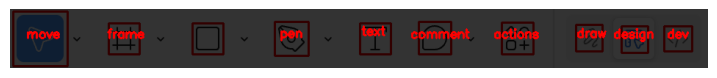

In [312]:
image = load_rgb('sample-data/figma-toolbar.png')
labels = extract_and_label_icons(image, smallest_ratio=0.005, largest_ratio=0.5)
imshow(labels, "labelled-toolbar.png")

## Scaling up SIFT

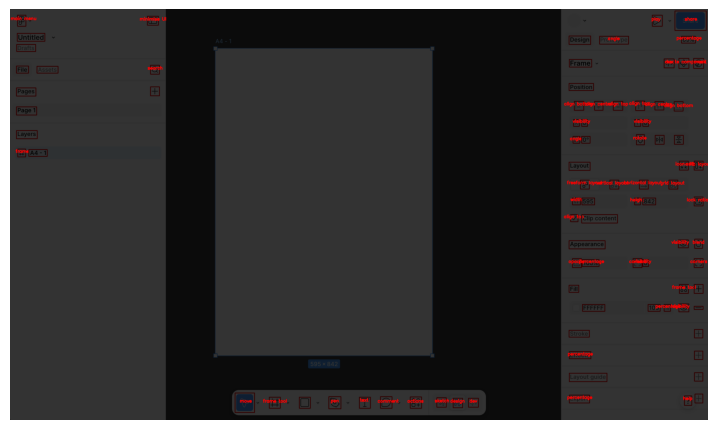

In [ ]:
image = load_rgb('sample-data/figma.png')
labels = extract_and_label_icons(image, dataset="icon-datasets/labelled-figma-dataset")
imshow(labels, "labelled-figma.png")

Another idea is to detect text for each label using ocr and if there is text remove it from the SIFT analysis - as text seems to get misclassified quite a lot.

As can be seen above this approach is not perfect - trying out different feature detectors could help - however the main issue is likely due to the icons being very small in scale and simple - meaning there are limited keypoints.

# Task 5 - Improving generalisability

This wouldn't scale up well for all GUI icons as I would need to manually label all of them. An alternative is to find some kind of tool that can produce labels for us - something like an object detection model / neural network could be helpful here.

Something like CLIP could be used, it is good at zero-shot classification: https://medium.com/@myscale/zero-shot-classification-with-openais-clip-6c50c25cf094 

Or something like a vision language model / ViT

I did a quick test of this in: vlm-test.ipynb - however results are quite limited as can be seen 
The predicted labels are in most casely significantly inaccurate
SIFT works better as it is much more predictable and stable.
